In [54]:
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import wasserstein_distance, spearmanr
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from skimage.metrics import structural_similarity as ssim
from matplotlib.colors import CenteredNorm
from torchview import draw_graph
from torchmetrics.functional.regression import r2_score as torch_r2_score
from torchmetrics.functional.image import structural_similarity_index_measure

from astral import moon

from io import BytesIO

from openpyxl.drawing.image import Image
import json


In [55]:
target_res = 0.125
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
split_year = 2022
min_time, max_time = pd.to_datetime("2009-01-01"), pd.to_datetime("2025-12-31")
sp = "HKP"
if sp == "GFW":
    fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp="HKP")
else:
    fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp=sp)
fishing = fishing_ds["cpue_index"]
fishing = fishing.fillna(0)

fishing_gfw_ds = xr.open_dataset("../data/processed/dynamic/GFW_ESP_TRAWL.nc")
fishing_gfw = fishing_gfw_ds["hours"]
fishing_gfw = np.log1p(fishing_gfw)
fishing_gfw = fishing_gfw.fillna(0)


peso = fishing_ds["PesoTotal"]/1000
peso = np.log1p(peso)
peso = peso.fillna(0)

effort = xr.open_dataset(f"../data/processed/targets/esfuerzo_{target_res}.nc")
effort = effort["Horas"]/24
effort = np.log1p(effort)
effort = effort.fillna(0)

mask_ds = xr.open_dataset(f"../data/processed/static/area_pesca_{target_res}.nc")
mask = mask_ds["mask"]
mask = mask.fillna(0)
mask = mask.broadcast_like(fishing)

temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp = temp_ds["to"]
# temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom_ds = temp_bottom_ds.rename({"to": "to_b"})
temp_bottom = temp_bottom_ds["to_b"]
# temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
# chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed = mixed_ds["mlotst"]
# mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth = depth_ds["depth"] 
# depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo = zo_ds["zo"]
# zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so = so_ds["so"]
# so = (so - so.mean()) / so.std()
so = so.fillna(0)

ugo_ds = xr.open_dataset("../data/processed/dynamic/ugo_surface.nc")
ugo = ugo_ds["ugo"]
# ugo = (ugo - ugo.mean()) / ugo.std()
ugo = ugo.fillna(0)

vgo_ds = xr.open_dataset("../data/processed/dynamic/vgo_surface.nc")
vgo = vgo_ds["vgo"]
# vgo = (vgo - vgo.mean()) / vgo.std()
vgo = vgo.fillna(0)

pp = xr.open_dataset("../data/processed/dynamic/pp.nc")
pp = pp["PP"]
# pp = (pp - pp.mean()) / pp.std()
pp = pp.fillna(0)

cdm = xr.open_dataset("../data/processed/dynamic/cdm.nc")
cdm = cdm["CDM"]
# cdm = (cdm - cdm.mean()) / cdm.std()
cdm = cdm.fillna(0)

spm = xr.open_dataset("../data/processed/dynamic/spm.nc")
spm = spm["SPM"]
# spm = (spm - spm.mean()) / spm.std()    
spm = spm.fillna(0)

zsd = xr.open_dataset("../data/processed/dynamic/zsd.nc")
zsd = zsd["ZSD"]
# zsd = (zsd - zsd.mean()) / zsd.std()
zsd = zsd.fillna(0)


month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month_sin.name = "month_sin"
month_cos.name = "month_cos"
month = month.broadcast_like(temp)

times = pd.DatetimeIndex(temp.time.values)
moon_ = np.array([moon.phase(t) for t in times])
moon_phase = xr.DataArray(moon_, coords={"time": temp.time}, dims=["time"], name="moon_phase")
# moon_phase = (moon_phase - moon_phase.mean()) / moon_phase.std()
moon_phase = moon_phase.fillna(0)
moon_phase = moon_phase.broadcast_like(temp)


year = temp["time"].dt.year
# year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)

lat = temp["lat"]
lon = temp["lon"]
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp)

temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, ugo, vgo, pp, cdm, spm, zsd, moon_phase, fishing_gfw_var = xr.align(
    temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, vgo, ugo, pp, cdm, spm, zsd, moon_phase, fishing_gfw, join="inner")

fishing, peso, effort, mask, fishing_gfw_T = xr.align(fishing, peso, effort, mask, fishing_gfw, join="inner")


#area de pesca y un poco alrededor
croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)

# area global
cropped = lambda da: da.sel(
    lon=slice(min_lon-0, max_lon+2),
    lat=slice(min_lat-4, max_lat+1),
    time=slice(min_time, max_time)
)

fishing = croppedT(fishing)
effort = croppedT(effort)    
mask = croppedT(mask)
peso = croppedT(peso)
fishing_gfw_T = croppedT(fishing_gfw_T)

temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
ugo = cropped(ugo)
vgo = cropped(vgo)
pp = cropped(pp)
cdm = cropped(cdm)
spm = cropped(spm)
zsd = cropped(zsd)
moon_phase = cropped(moon_phase)
fishing_gfw_var = cropped(fishing_gfw_var)



In [56]:
y = fishing
if sp == "GFW":
    y = fishing_gfw_T

y = y.transpose("time", "lat", "lon")

m = mask 
m = m.transpose("time", "lat", "lon")


vars_ = [temp, #temp_bottom,
        #so, zo,
        ugo, vgo, mixed,
        cdm, #chl, pp,
        month_sin, month_cos,
        # moon_phase,
        # lat, lon,
        # depth,
        # year,
        # fishing_gfw_var,
        ]

if sp == "GFW":
    vars_.append(fishing_gfw_var)


vars_names = [v.name for v in vars_]
in_channels = len(vars_)
X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")
print(X.shape)
print(y.shape)
print(m.shape)



train_X = X.sel(time=slice(None, f"{split_year-1}-12-31"))
test_X  = X.sel(time=slice(f"{split_year}-01-01", None))

train_y = y.sel(time=slice(None, f"{split_year-1}-12-31"))
test_y  = y.sel(time=slice(f"{split_year}-01-01", None))

m_train = m.sel(time=slice(None, f"{split_year-1}-12-31"))
m_test  = m.sel(time=slice(f"{split_year}-01-01", None))

# -------- Data Standardization (Z-score Normalization) --------
# 1. Assign your variable names to the channel coordinate for explicit targeting
train_X = train_X.assign_coords(channel=vars_names)
test_X  = test_X.assign_coords(channel=vars_names)
epsilon = 1e-8 #avoids division by zero

# 2. Calculate mean and standard deviation across space and time
train_mean = train_X.mean(dim=["time", "lat", "lon"], skipna=True)
train_std  = train_X.std(dim=["time", "lat", "lon"], skipna=True)


# 3. Set mean=0 and std=1 for cyclical features so they bypass scaling
# (Subtracting 1e-8 ensures the denominator becomes exactly 1.0 when epsilon is added)
for feat in ["month_sin", "month_cos"]:
    if feat in train_mean.coords["channel"].values:
        train_mean.loc[dict(channel=feat)] = 0.0
        train_std.loc[dict(channel=feat)] = 1.0 - epsilon

# 4. Apply the transformation natively across the entire DataArray
train_X = (train_X - train_mean) / (train_std + epsilon)
test_X  = (test_X - train_mean) / (train_std + epsilon)


def create_windows(X, y, m, window=12):
    X_data = X.values   # (time, channels, H, W)
    y_data = y.values   # (time, H, W)
    m_data = m.values   # (time, H, W)

    X_seq, y_seq, m_seq= [], [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window]) #12 months
        y_seq.append(y_data[i+window]) #next month
        m_seq.append(m_data[i+window]) #next month
        

    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_seq), dtype=torch.float32),
    )

window = 12 #months

X_train, y_train, m_train = create_windows(train_X, train_y, m_train, window)
X_test, y_test, m_test = create_windows(test_X, test_y, m_test, window)

print(X_train.shape, X_test.shape)  # (N, T, C, H, W)
print(y_train.shape, y_test.shape)  # (N, H, W)
print(m_train.shape, m_test.shape)  # (N, H, W)
###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train, m_train),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test, m_test),
    batch_size=batch_size,
    shuffle=False
)


(168, 7, 62, 25)
(168, 30, 17)
(168, 30, 17)
torch.Size([108, 12, 7, 62, 25]) torch.Size([36, 12, 7, 62, 25])
torch.Size([108, 30, 17]) torch.Size([36, 30, 17])
torch.Size([108, 30, 17]) torch.Size([36, 30, 17])


In [ ]:
# -------- Basic Conv Block --------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(),
            nn.Dropout3d(0.3),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(),
            )

    def forward(self, x):
        return self.block(x)

# -------- Decoder Block --------
class DecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, (1, 2, 2), stride=(1, 2, 2))
        self.conv_block = ConvBlock(out_channels + skip_channels, out_channels)
        
    def forward(self, x, skip):
        x = self.up(x)

        # Handle size mismatches
        x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)

        x = self.conv_block(x)
        return x

# -------- Temporal Aggregation Block --------
class TemporalAggregationBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.temporal_attn = nn.Sequential(
            nn.Conv3d(in_channels, in_channels, kernel_size=(3, 1, 1), padding=(1, 0, 0), groups=in_channels),
            nn.Sigmoid()
        )
        self.temporal_score = nn.Conv3d(in_channels, 1, kernel_size=1)
    
    def forward(self, x):
        # x shape: (B, C, T, H, W)
        attn = self.temporal_attn(x)
        feat = x * attn
        score = self.temporal_score(feat)
        weights = torch.softmax(score, dim=2) 
        feat = (feat * weights).sum(dim=2)    
        return feat

# -------- Global Attention Branch --------
class GlobalAttentionBranch(nn.Module):
    def __init__(self, channels, time_pooling=None):
        super().__init__()
        reduction = max(channels // 4, 8)
        self.branch = nn.Sequential(
            nn.AdaptiveAvgPool3d((time_pooling, 1, 1)),
            nn.Conv3d(channels, reduction, 1),
            nn.PReLU(reduction),
            nn.Conv3d(reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.branch(x)
    
# -------- Temporal Mixing Block --------
class TemporalMixBlock(nn.Module):
    def __init__(self, channels, window_size=5):
        super().__init__()
        
        # Enforce odd window size to ensure symmetric padding across time
        if window_size % 2 == 0:
            raise ValueError(f"window_size must be odd (3, 5, 7), got {window_size}")
        pad_t = window_size // 2

        self.mix = nn.Sequential(
            nn.Conv3d(channels, channels, kernel_size=(window_size, 1, 1), padding=(pad_t, 0, 0)),
            nn.BatchNorm3d(channels),
            nn.PReLU(channels)
        )

    def forward(self, x):
        return x + self.mix(x)
    
class RegressionHead(nn.Module):

    def __init__(self, base_ch: int, out_channels: int, out_hw: tuple):
        
        super(RegressionHead, self).__init__()
        self.out_hw = out_hw
        self.refinement= nn.Sequential(
            nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.PReLU(base_ch),
        )
        
        self.regressor = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.PReLU(base_ch),
            nn.Conv2d(base_ch, out_channels, kernel_size=1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.refinement(x)

        # Interpolate spatial dimensions to match out_hw
        x = F.interpolate(x, size=self.out_hw, mode="bilinear", align_corners=False)
        
        # Apply regression layers
        out = self.regressor(x)

        return out
    

In [58]:
# -------- U-Net 3D temporal collapse after bottleneck --------
class UNet3D(nn.Module):
    def __init__(self, in_channels, out_hw, out_channels=1, base_ch=8):
        super().__init__()

        self.out_hw = out_hw  # (H, W)

        # -------- Encoder --------
        self.enc1 = ConvBlock(in_channels, base_ch)
        self.pool1 = nn.MaxPool3d((1, 2, 2))


        self.enc2 = ConvBlock(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d((1, 2, 2))
        # -------- Bottleneck --------
        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 4)
        self.temp_mix = TemporalMixBlock(base_ch * 4, window_size=7)
        self.global_att = GlobalAttentionBranch(base_ch * 4)
        
        # -------- Decoder --------
        self.decoder2 = DecoderBlock3D(base_ch * 4, base_ch * 2, base_ch * 2)
        self.decoder1 = DecoderBlock3D(base_ch * 2, base_ch, base_ch)
    
        # -------- Temporal Aggregation --------
        self.temporal_agg = TemporalAggregationBlock(base_ch)

        # -------- Regression Head --------
        self.regression_head = RegressionHead(base_ch=base_ch, out_channels=out_channels, out_hw=self.out_hw)

    def forward(self, x, mask=None):
        # INPUT COMES AS: (B, T, C, H, W) Convert to:(B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        
        # -------- Encoder --------
        s1 = self.enc1(x)
        p1 = self.pool1(s1)


        s2 = self.enc2(p1)
        p2 = self.pool2(s2)


        # -------- Bottleneck --------
        b = self.bottleneck(p2)
        b = self.temp_mix(b)     
        b = b * self.global_att(b)

        # -------- Decoder --------
        d2 = self.decoder2(b, s2)
        d1 = self.decoder1(d2, s1)

        # -------- Temporal Aggregation --------
        final_2d = self.temporal_agg(d1)
        
        # -------- Regression Head --------
        out = self.regression_head(final_2d)
        
  


        if mask is not None:
            # Match out shape: (B, 1, H, W)
            out = out * mask.unsqueeze(1).float()
        return out

In [59]:
class StackedCNN3D(nn.Module):
    def __init__(self, in_channels, out_hw, out_channels=1, base_ch=10):
        super().__init__()
        
        self.out_hw = out_hw  # (H, W)
        self.out_channels = out_channels
        
        # --- Stage 1: Low-Level Feature Extraction ---
        # Processes raw environmental inputs at full resolution
        self.stage1 = ConvBlock(in_channels, base_ch)

        
        # --- Stage 2: Contextual & Attention Mapping ---
        # Elevates channel capacity to capture joint environmental correlations
        self.stage2 = ConvBlock(base_ch, base_ch * 2)
        self.temp_mix1 = TemporalMixBlock(base_ch*2, window_size=5)
        self.global_att = GlobalAttentionBranch(base_ch * 2)
        
        # --- Stage 3: Feature Refinement ---
        # Brings channels back down and smooths features before collapsing time
        self.stage3_1 = ConvBlock(base_ch * 2, base_ch*4)
        self.stage3 = ConvBlock(base_ch * 4, base_ch*2)
        self.stage3_2 = ConvBlock(base_ch*2, base_ch)
        
        # --- Temporal Aggregation ---
        # Your learned softmax mechanism to collapse the 12 months down to 2D
        self.temporal_agg = TemporalAggregationBlock(base_ch)
        
        # -------- Regression Head --------
        self.regression_head = RegressionHead(base_ch=base_ch, out_channels=out_channels, out_hw=self.out_hw)

    def forward(self, x, mask=None):
        # Input shape: (B, T, C, H, W) -> Convert to: (B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        
        # --- Forward Stage 1 ---
        x = self.stage1(x)

        # --- Forward Stage 2 ---
        x = self.stage2(x)

        # --- Forward Stage 3 ---
        x = self.stage3_1(x)
        x = self.stage3(x)

        x = self.temp_mix1(x)
        x = x * self.global_att(x)

        x = self.stage3_2(x)
        
        # --- Collapse Time Dimension ---
        final_2d = self.temporal_agg(x)  # Results in (B, C, H, W)
        
        
        # --- Map to CPUE Prediction ---
        out = self.regression_head(final_2d)
        
        # Apply land/sea mask if provided
        if mask is not None:
            out = out * mask.unsqueeze(1).float()
            
        return out

In [60]:
# -------- SSIM loss functions --------
def huber_SSIM_loss(pred, target, mask, ssim_weight=1.0, huber_delta=1.0, window_size=7):
    """
    pred:   (B, 1, H, W)
    target: (B, H, W)
    mask:   (B, H, W)
    """
    # Ensure window_size is odd to preserve spatial dimensions
    if window_size % 2 == 0:
        window_size += 1
        
    # Ensure target and mask match pred shape: (B, 1, H, W)
    target = target.unsqueeze(1)
    mask = mask.unsqueeze(1).float()
    
    # Calculate valid pixels to average the loss correctly
    valid_pixels = mask.sum().clamp(min=1e-8)
    
    # -------- 1. Huber Loss --------
    huber_map = F.huber_loss(pred, target, delta=huber_delta, reduction='none')
    huber = (huber_map * mask).sum() / valid_pixels
    
    # -------- 2. Differentiable SSIM Loss --------
    data_range = target.max() - target.min() + 1e-8
    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2

    # Using avg_pool2d as a fast, uniform sliding window
    pad = window_size // 2
    
    mu_pred = F.avg_pool2d(pred, window_size, stride=1, padding=pad)
    mu_target = F.avg_pool2d(target, window_size, stride=1, padding=pad)

    sigma_pred_sq = F.avg_pool2d(pred**2, window_size, stride=1, padding=pad) - mu_pred**2
    sigma_target_sq = F.avg_pool2d(target**2, window_size, stride=1, padding=pad) - mu_target**2
    sigma_pt = F.avg_pool2d(pred * target, window_size, stride=1, padding=pad) - mu_pred * mu_target

    # SSIM Formula
    numerator = (2 * mu_pred * mu_target + C1) * (2 * sigma_pt + C2)
    denominator = (mu_pred**2 + mu_target**2 + C1) * (sigma_pred_sq + sigma_target_sq + C2)
    
    ssim_map = numerator / denominator
    
    # Apply mask to SSIM map
    ssim_loss_val = 1.0 - (ssim_map * mask).sum() / valid_pixels
    
    # -------- Combine -------- 
    return huber + (ssim_weight * ssim_loss_val)


def MSE_SSIM_loss(pred, target, mask, ssim_weight=0.5, window_size=7):
    """
    pred:   (B, 1, H, W)
    target: (B, H, W)
    mask:   (B, H, W)
    """
    # Ensure window_size is odd to preserve spatial dimensions
    if window_size % 2 == 0:
        window_size += 1
        
    # Ensure target and mask match pred shape: (B, 1, H, W)
    target = target.unsqueeze(1)
    mask = mask.unsqueeze(1).float()
    
    # Calculate valid pixels to average the loss correctly
    valid_pixels = mask.sum().clamp(min=1e-8)
    
    # -------- 1. MSE Loss --------
    mse_map = F.mse_loss(pred, target, reduction='none')
    mse = (mse_map * mask).sum() / valid_pixels
    
    # -------- 2. Differentiable SSIM Loss --------
    data_range = target.max() - target.min() + 1e-8
    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2

    # Using avg_pool2d as a fast, uniform sliding window
    pad = window_size // 2
    
    mu_pred = F.avg_pool2d(pred, window_size, stride=1, padding=pad)
    mu_target = F.avg_pool2d(target, window_size, stride=1, padding=pad)

    sigma_pred_sq = F.avg_pool2d(pred**2, window_size, stride=1, padding=pad) - mu_pred**2
    sigma_target_sq = F.avg_pool2d(target**2, window_size, stride=1, padding=pad) - mu_target**2
    sigma_pt = F.avg_pool2d(pred * target, window_size, stride=1, padding=pad) - mu_pred * mu_target

    # SSIM Formula
    numerator = (2 * mu_pred * mu_target + C1) * (2 * sigma_pt + C2)
    denominator = (mu_pred**2 + mu_target**2 + C1) * (sigma_pred_sq + sigma_target_sq + C2)
    
    ssim_map = numerator / denominator
    
    # Apply mask to SSIM map
    ssim_loss_val = 1.0 - (ssim_map * mask).sum() / valid_pixels
    
    # -------- Combine --------
    return mse + (ssim_weight * ssim_loss_val)

In [61]:
#-------- Custom Geospatial Loss Module --------
class GeospatialLoss(nn.Module):
    def __init__(self, ssim_weight=1.0, window_size=7, huber_delta=1.0):
        super().__init__()
        self.ssim_weight = ssim_weight
        self.window_size = window_size
        self.huber_delta = huber_delta

    def forward(self, pred, target, mask):
        """
        pred:   (B, 1, H, W)
        target: (B, H, W)
        mask:   (B, H, W)
        """
        # Ensure target and mask match prediction dimensions
        target = target.unsqueeze(1) 
        mask = mask.unsqueeze(1).float() # (B, 1, H, W)
        
        # 1. Huber Loss: Computed pixel-wise, then masked and averaged
        base_loss = F.huber_loss(pred, target, reduction='none', delta=self.huber_delta)
        masked_base_loss = (base_loss * mask).sum() / (mask.sum() + 1e-8)
        
        # 2. Fully Differentiable Masked SSIM
        ssim_loss = self._differentiable_ssim(pred, target, mask)
        
        return masked_base_loss + (self.ssim_weight * ssim_loss)

    def _differentiable_ssim(self, pred, target, mask):
        # Capture target spatial dimensions to prevent padding overshoots
        _, _, H, W = pred.shape
        
        # Apply mask
        valid = mask > 0
        pred_masked = torch.where(valid, pred, torch.zeros_like(pred))
        target_masked = torch.where(valid, target, torch.zeros_like(target))

        # Dynamically calculate the data range per image in the batch
        max_val = target_masked.amax(dim=(2, 3), keepdim=True)
        min_val = target_masked.amin(dim=(2, 3), keepdim=True)

        data_range = max_val - min_val + 1e-8
        
        C1 = (0.01 * data_range) ** 2
        C2 = (0.03 * data_range) ** 2

        pad = self.window_size // 2

        # Calculate means using avg_pool2d
        # Note: stride=1 is required to ensure the output spatial dimensions match the input
        mu1 = F.avg_pool2d(pred_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W]
        mu2 = F.avg_pool2d(target_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W]

        mu1_sq, mu2_sq, mu1_mu2 = mu1 ** 2, mu2 ** 2, mu1 * mu2

        # Calculate variances using avg_pool2d
        sigma1_sq = F.avg_pool2d(pred_masked * pred_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W] - mu1_sq
        sigma2_sq = F.avg_pool2d(target_masked * target_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W] - mu2_sq
        sigma12 = F.avg_pool2d(pred_masked * target_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W] - mu1_mu2

        # SSIM map calculation
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        
        # Apply mask to SSIM map safely
        masked_ssim = (ssim_map * mask).sum() / (mask.sum() + 1e-8)
        
        # Minimize loss -> return 1 - SSIM
        return 1.0 - masked_ssim

In [62]:
# -------------- Training Loop --------------
dry_run=True


iters = 10
list_of_r2_train = []
list_of_r2_val = []
list_of_train_loss = []
list_of_val_loss = []

for i in range(iters):
    
    print(f"----------------------------------------------------Iteration {i+1}/{iters}-----------------------------------------------------------------------")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    out_hw = y_train.shape[1:]

    model = UNet3D(in_channels=in_channels, out_hw=out_hw, 
                base_ch=12
                ).to(device)
    
    model_name = model.__class__.__name__

    criterion = GeospatialLoss(ssim_weight=0.8, huber_delta=4).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=10e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=20)

    best_test_r2 = -float("inf")
    best_test_ssim = -float("inf")
    best_combined_score = float("-inf")
    best_model_path = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}.pth"

    patience = 40
    epochs = 300
    counter = 0

    train_r2_history = []
    val_r2_history = []
    train_loss_history = []
    val_loss_history = []
    
    test_ssim_history = [] 

    # -------- Training loop --------
    for epoch in range(epochs):

        # -------- Training --------
        model.train()
        total_loss = 0.0
        train_r2s = []

        for x, y, m in train_loader:
        # for x, y, m in train_residual_loader:

            x = x.to(device)      # (B,T,C,H,W)
            y = y.to(device)      # (B,H,W)
            m = m.to(device)      # (B,H,W)

            optimizer.zero_grad()
            pred = model(x)       # (B,1,H,W)

            # ----- Loss -----
            loss = criterion(pred, y, m)
            # loss = MSE_SSIM_loss(pred, y, m, ssim_weight=1.0)
            # loss = huber_SSIM_loss(pred, y, m, ssim_weight=0.5, huber_delta=0.5)

            loss.backward()
            optimizer.step()

            total_loss += loss.detach()
            # ----- Metrics -----
            pred_np = pred.detach().cpu().squeeze(1).numpy()   # (B,H,W)
            y_np = y.detach().cpu().numpy()                    # (B,H,W)
            m_np = m.detach().cpu().numpy()                    # (B,H,W)
            
            # Flatten and filter by mask
            y_true = y_np.reshape(-1)
            y_pred = pred_np.reshape(-1)
            m_flat = m_np.reshape(-1)
            
            valid_idx = m_flat > 0.5 
            y_true_valid = y_true[valid_idx]
            y_pred_valid = y_pred[valid_idx]

            if len(y_true_valid) > 1:
                train_r2s.append(r2_score(y_true_valid, y_pred_valid))
        epoch_train_loss = (total_loss / len(train_loader)).cpu().item()
        train_loss_history.append(epoch_train_loss)
        train_r2 = np.mean(train_r2s) if len(train_r2s) > 0 else float("nan")
        # =====================================================
        # -------- Validation --------
        # =====================================================
        model.eval()

        # Lists to accumulate flat masked data for global regression metrics
        all_y_true_valid = []
        all_y_pred_valid = []
        
        # SSIM is an image-level metric, so we still accumulate it per-image
        test_ssims = []

        total_val_loss = 0.0
        with torch.no_grad():
            for x, y, m in test_loader:
            # for x, y, m in test_residual_loader:
                x = x.to(device)
                y = y.to(device)
                m = m.to(device)

                pred = model(x)
                loss = criterion(pred, y, m)
                total_val_loss += loss.detach().item()
                # ----- Convert to numpy -----
                pred_np = pred.detach().cpu().squeeze(1).numpy()
                y_np = y.detach().cpu().numpy()
                m_np = m.detach().cpu().numpy()

                # ----- 1. Accumulate Global Data for Regression Metrics -----
                y_true_flat = y_np.reshape(-1)
                y_pred_flat = pred_np.reshape(-1)
                m_flat = m_np.reshape(-1)
                
                valid_idx = m_flat > 0.5
                
                # Append only the valid pixels to our global lists
                all_y_true_valid.append(y_true_flat[valid_idx])
                all_y_pred_valid.append(y_pred_flat[valid_idx])

                # ----- 2. Masked SSIM Calculation (Per Image) -----
                y_np_spatial = y_np.reshape(pred_np.shape)
                m_np_spatial = m_np.reshape(pred_np.shape)
                
                data_range = 1.0 
                for i in range(len(pred_np)):
                    min_dim = min(y_np_spatial[i].shape)  
                    win_size = min(11, min_dim)
                    if win_size % 2 == 0:
                        win_size -= 1
                    if win_size < 3: 
                        win_size = 3
                    
                    _, ssim_img = ssim(
                        y_np_spatial[i], 
                        pred_np[i], 
                        data_range=data_range, 
                        win_size=win_size, 
                        gaussian_weights=True, 
                        full=True
                    )
                    
                    valid_mask = m_np_spatial[i] > 0.5
                    if valid_mask.sum() > 0:
                        masked_score = ssim_img[valid_mask].mean()
                        test_ssims.append(masked_score)
            epoch_val_loss = total_val_loss / len(test_loader)
            val_loss_history.append(epoch_val_loss)
        # =====================================================
        # ----- Final Global Metric Computation -----
        # =====================================================
        
        # Concatenate all batches into single 1D arrays
        if len(all_y_true_valid) > 0:
            global_y_true = np.concatenate(all_y_true_valid)
            global_y_pred = np.concatenate(all_y_pred_valid)
        else:
            global_y_true, global_y_pred = np.array([]), np.array([])

        # Compute global regression metrics
        if len(global_y_true) > 1:
            test_r2 = r2_score(global_y_true, global_y_pred)
            test_mae = mean_absolute_error(global_y_true, global_y_pred)
            test_bias = np.mean(global_y_pred - global_y_true)
            
            # Protect pearson from perfectly flat arrays
            if np.std(global_y_true) > 0 and np.std(global_y_pred) > 0:
                test_corr = pearsonr(global_y_true, global_y_pred)[0]
            else:
                test_corr = float("nan")
        else:
            test_r2 = float("nan")
            test_mae = float("nan")
            test_bias = float("nan")
            test_corr = float("nan")

        # Average the valid image-level SSIMs
        test_ssim = np.mean(test_ssims) if len(test_ssims) > 0 else float("nan")
        # =====================================================
        # -------- Early stopping --------
        # =====================================================
        improved = False
        scheduler.step(test_r2)
        if test_r2 > best_test_r2:
            best_test_r2 = test_r2
            improved = True
        if test_ssim > best_test_ssim:
            best_test_ssim = test_ssim
            improved = True
        
        combined_score = 0.8*test_r2 + 0.2*test_ssim
        if combined_score > best_combined_score:
            best_combined_score = combined_score
            improved = True
            torch.save(model.state_dict(), best_model_path)
            print("Saved")
                
        if improved:
            counter = 0
        else:
            counter += 1
            
        if counter >= patience:
            print("Early stopping")
            break

        # -------- Logging --------
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {total_loss/len(train_loader):.4f} | "
            f"Train R2: {train_r2:.3f} | "
            f"R2: {test_r2:.3f} | "
            f"Best R2: {best_test_r2:.3f} | "
            f"Best Score: {best_combined_score:.3f} | "
            f"SSIM: {test_ssim:.3f} | "
            f"BestSSIM: {best_test_ssim:.3f} | "
            f"Bias: {test_bias:.3f} | "
            f"Corr: {test_corr:.3f}"
        )

        train_r2_history.append(train_r2)
        val_r2_history.append(test_r2)

    list_of_r2_train.append(train_r2_history)
    list_of_r2_val.append(val_r2_history)
    list_of_train_loss.append(train_loss_history)
    list_of_val_loss.append(val_loss_history)

if not dry_run:
    data = {
        "list_of_r2_train": list_of_r2_train,
        "list_of_r2_val": list_of_r2_val,
        "list_of_train_loss": list_of_train_loss,
        "list_of_val_loss": list_of_val_loss
    }

    with open(f"./modelos/runs/Regression/tloop_{model_name}_{sp}.json", "w") as file:
        json.dump(data, file, indent=2)


----------------------------------------------------Iteration 1/10-----------------------------------------------------------------------
Saved
Epoch 1/300 | Loss: 4.5743 | Train R2: -0.356 | R2: -0.584 | Best R2: -0.584 | Best Score: -0.467 | SSIM: 0.001 | BestSSIM: 0.001 | Bias: -1.995 | Corr: 0.122
Saved
Epoch 2/300 | Loss: 3.5918 | Train R2: -0.035 | R2: -0.577 | Best R2: -0.577 | Best Score: -0.461 | SSIM: 0.003 | BestSSIM: 0.003 | Bias: -1.995 | Corr: 0.366
Saved
Epoch 3/300 | Loss: 3.0454 | Train R2: 0.127 | R2: -0.422 | Best R2: -0.422 | Best Score: -0.331 | SSIM: 0.031 | BestSSIM: 0.031 | Bias: -1.835 | Corr: 0.562
Saved
Epoch 4/300 | Loss: 2.7273 | Train R2: 0.223 | R2: -0.285 | Best R2: -0.285 | Best Score: -0.214 | SSIM: 0.067 | BestSSIM: 0.067 | Bias: -1.667 | Corr: 0.581
Saved
Epoch 5/300 | Loss: 2.6544 | Train R2: 0.247 | R2: -0.113 | Best R2: -0.113 | Best Score: -0.065 | SSIM: 0.127 | BestSSIM: 0.127 | Bias: -1.460 | Corr: 0.591
Saved
Epoch 6/300 | Loss: 2.4472 | Train

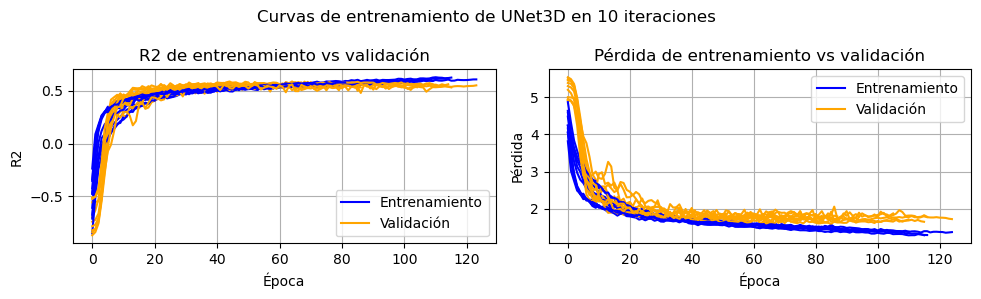

0

In [63]:
with open(f"./modelos/runs/Regression/tloop_{model_name}_{sp}.json", "r") as file:
    data = json.load(file)
list_of_r2_train = data["list_of_r2_train"]
list_of_r2_val = data["list_of_r2_val"]
list_of_train_loss = data["list_of_train_loss"]
list_of_val_loss = data["list_of_val_loss"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.suptitle(f"Curvas de entrenamiento de {model_name} en {iters} iteraciones", fontsize=12)
for i in range(len(list_of_r2_train) - 1):
    axes[0].plot(list_of_r2_train[i], color="blue")
    axes[0].plot(list_of_r2_val[i], color="orange")
axes[0].plot(list_of_r2_train[-1], color="blue", label="Entrenamiento")
axes[0].plot(list_of_r2_val[-1], color="orange", label="Validación")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 de entrenamiento vs validación")
axes[0].grid(True)
axes[0].legend()

for i in range(len(list_of_train_loss) - 1):
    axes[1].plot(list_of_train_loss[i], color="blue")
    axes[1].plot(list_of_val_loss[i], color="orange")
axes[1].plot(list_of_train_loss[-1], color="blue", label="Entrenamiento")
axes[1].plot(list_of_val_loss[-1], color="orange", label="Validación")

axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
axes[1].set_title("Pérdida de entrenamiento vs validación")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)


In [64]:
def regression_metrics_dl(y_true, y_pred, mask_spatial):
    mask_bool = mask_spatial.astype(bool)


    # =====================================================
    # 1. FLATTEN FOR METRICS
    # =====================================================
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    if mask_bool.ndim == 2:
        mask_flat = np.broadcast_to(mask_bool, y_true.shape).flatten()
    else:
        mask_flat = mask_bool.flatten()

    y_test_masked = y_true_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]

    # =====================================================
    # 2. REGRESSION METRICS
    # =====================================================
    rmse = np.sqrt(mean_squared_error(y_test_masked, y_pred_masked))
    mae = mean_absolute_error(y_test_masked, y_pred_masked)
    r2 = r2_score(y_test_masked, y_pred_masked)
    pearson_corr = pearsonr(y_test_masked, y_pred_masked)[0]
    mbe = np.mean(y_pred_masked - y_test_masked)
    data_range_flat = np.max(y_test_masked) - np.min(y_test_masked)
    nrmse = rmse / data_range_flat

    w_dist = wasserstein_distance(y_test_masked, y_pred_masked)
    spearman_corr, p_val = spearmanr(y_test_masked, y_pred_masked)


    print("RMSE:", f"{rmse:.4f}")
    print(f"Normalized RMSE: {nrmse:.4f} ({nrmse*100:.2f}%)")
    print("MAE:", f"{mae:.4f}")
    print("R2:", f"{r2:.4f}")
    print("Pearson R:", f"{pearson_corr:.4f}")
    print("MBE:", f"{mbe:.4f}")
    print(f"Wasserstein Distance: {w_dist:.4f}")
    print(f"Spearman Rank Correlation: {spearman_corr:.2f}")


    # =====================================================
    # HOTSPOT Hit Rate
    # =====================================================
    percentile = 80
    hotspot_threshold_true = np.percentile(y_test_masked, percentile)
    hotspot_threshold_pred = np.percentile(y_pred_masked, percentile)

    # Create boolean masks for the top 20%
    actual_hotspots = (y_test_masked >= hotspot_threshold_true)
    pred_hotspots = (y_pred_masked >= hotspot_threshold_pred)

    # Count how many points are in the true top 20%
    total_actual_hotspots = np.sum(actual_hotspots)

    # Count how many points are in BOTH the true top 20% AND predicted top 20%
    shared_hotspots = np.sum(actual_hotspots & pred_hotspots)

    # Calculate the Hit Rate percentage
    hit_rate = shared_hotspots / total_actual_hotspots
    hit_rate_percent = hit_rate * 100

    print(f"\n--- Hotspot Hit Rate (Top {100-percentile}% Overlap) ---")
    print(f"Total Hit Rate                        : {hit_rate_percent:.4f}%")

    # =====================================================
    # YEARLY HOTSPOT Hit Rate
    # =====================================================
    percentile = 80
    
    # Rebuild 3D shape to iterate over time (months)
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D_temp = y_pred_flat.reshape(-1, H_out, W_out)
    
    total_actual_hotspots_yearly_all = 0
    shared_hotspots_yearly_all = 0
    yearly_hit_rates = []
    
    # Iterate through the time dimension in 12-month chunks (years)
    for year_idx in range(0, y_true.shape[0], 12):
        end_idx = min(year_idx + 12, y_true.shape[0])
        
        # Handle the spatial mask safely across a multi-month block
        if mask_spatial.ndim == 3:
            current_mask = mask_spatial[year_idx:end_idx].astype(bool)
            y_true_year = y_true[year_idx:end_idx][current_mask]
            y_pred_year = y_pred3D_temp[year_idx:end_idx][current_mask]
        else:
            current_mask = mask_spatial.astype(bool)
            # Extract valid pixels spatially across the 12-month chunk, then flatten
            y_true_year = y_true[year_idx:end_idx][:, current_mask].flatten()
            y_pred_year = y_pred3D_temp[year_idx:end_idx][:, current_mask].flatten()
        
        # Skip if mask leaves no valid pixels for this year chunk
        if len(y_true_year) == 0:
            continue
            
        # Calculate the 80th percentile threshold for THIS specific year
        thresh_true_year = np.percentile(y_true_year, percentile)
        thresh_pred_year = np.percentile(y_pred_year, percentile)
        
        # Create boolean masks for the top 20%
        actual_hotspots_year = (y_true_year >= thresh_true_year)
        pred_hotspots_year = (y_pred_year >= thresh_pred_year)
        
        # Count overlaps
        total_actual_year = np.sum(actual_hotspots_year)
        shared_year = np.sum(actual_hotspots_year & pred_hotspots_year)
        
        # Keep running totals for the aggregate score
        total_actual_hotspots_yearly_all += total_actual_year
        shared_hotspots_yearly_all += shared_year
        
        # Calculate hit rate strictly for this year
        if total_actual_year > 0:
            yearly_hit_rates.append((shared_year / total_actual_year) * 100)

    # Calculate final aggregate metrics across all years
    mean_yearly_hit_rate = np.mean(yearly_hit_rates) if yearly_hit_rates else 0
    
    print(f"Mean Yearly Hit Rate                : {mean_yearly_hit_rate:.3f}%")
    
    # =====================================================
    # MONTHLY HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    
    # Rebuild 3D shape to iterate over time (months)
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D_temp = y_pred_flat.reshape(-1, H_out, W_out)
    
    total_actual_hotspots_all = 0
    shared_hotspots_all = 0
    monthly_hit_rates = []
    
    # Iterate through each month (time step)
    for i in range(y_true.shape[0]):
        
        # Handle the spatial mask safely (whether it is 2D or 3D)
        current_mask = mask_spatial[i] if mask_spatial.ndim == 3 else mask_spatial
        current_mask = current_mask.astype(bool)
        # Extract valid pixels strictly for this month
        y_true_month = y_true[i][current_mask]
        y_pred_month = y_pred3D_temp[i][current_mask]
        
        # Skip if mask leaves no valid pixels for this month
        if len(y_true_month) == 0:
            continue
            
        # Calculate the 80th percentile threshold for THIS specific month
        thresh_true = np.percentile(y_true_month, percentile)
        thresh_pred = np.percentile(y_pred_month, percentile)
        
        # Create boolean masks for the top 20%
        actual_hotspots_month = (y_true_month >= thresh_true)
        pred_hotspots_month = (y_pred_month >= thresh_pred)
        
        # Count overlaps
        total_actual = np.sum(actual_hotspots_month)
        shared = np.sum(actual_hotspots_month & pred_hotspots_month)
        
        # Keep running totals for the aggregate score
        total_actual_hotspots_all += total_actual
        shared_hotspots_all += shared
        
        # Calculate hit rate strictly for this month
        if total_actual > 0:
            monthly_hit_rates.append((shared / total_actual) * 100)

    # Calculate final aggregate metrics across all months
    mean_monthly_hit_rate = np.mean(monthly_hit_rates)
    print(f"Mean Monthly Hit Rate               : {mean_monthly_hit_rate:.3f}%")

    # =====================================================
    # 4. MASKED SSIM
    # =====================================================
    data_range = 1.0 
    ssim_scores = []

    for i in range(y_true.shape[0]):
        _, ssim_map = ssim(
            y_true[i], y_pred[i],
            data_range=data_range, 
            win_size=11,           # Standard size
            gaussian_weights=True, # Weights center pixels more, like human vision
            full=True
        )
        current_mask = mask_bool if mask_bool.ndim == 2 else mask_bool[i]
        valid_ssim_pixels = ssim_map[current_mask]

        if len(valid_ssim_pixels) > 0:
            ssim_scores.append(np.mean(valid_ssim_pixels))

    mean_ssim = np.mean(ssim_scores)
    print(f"Mean Masked SSIM: {mean_ssim:.4f}\n")

    # =====================================================
    # 5. PLOTTING (MASKED)
    # =====================================================
    if mask_bool.ndim == 3:
        mean_mask_2d = mask_bool[0] 
    else:
        mean_mask_2d = mask_bool

    # Compute means over time axis
    y_pred_mean = np.mean(y_pred, axis=0)
    y_true_mean = np.mean(y_true, axis=0)
    error = y_pred_mean - y_true_mean

    # Apply spatial mask by setting invalid regions to NaN
    y_true_mean_masked = np.where(mean_mask_2d, y_true_mean, np.nan)
    y_pred_mean_masked = np.where(mean_mask_2d, y_pred_mean, np.nan)
    error_masked = np.where(mean_mask_2d, error, np.nan)
    
    y_true_plot1 =  np.nan_to_num(y_true_mean_masked, nan=0)
    y_pred_plot1 = np.nan_to_num(y_pred_mean_masked, nan=0)

    plt.figure(figsize=(12, 4))

    ax1 = plt.subplot(1, 3, 1)
    plt.title("Mean Test Truth")
    plt.imshow(y_true_plot1, cmap='viridis')
    plt.colorbar()
    ax1.invert_yaxis()

    ax2 = plt.subplot(1, 3, 2)
    plt.title("Mean Test Prediction")
    plt.imshow(y_pred_plot1, cmap='viridis')
    plt.colorbar()
    ax2.invert_yaxis()

    ax3 = plt.subplot(1, 3, 3)
    plt.title("Mean Error (Pred - True)")
    # Using symmetric limits around zero so 'coolwarm' centers beautifully
    vmax = np.nanmax(np.abs(error_masked)) if not np.isnan(error_masked).all() else 1.0
    plt.imshow(error_masked, cmap='coolwarm', norm=CenteredNorm())
    plt.colorbar()
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # =====================================================
    # TIME SERIES COMPARISON (MASKED)
    # =====================================================
    y_true_time = []
    y_pred_time = []

    for i in range(y_true.shape[0]):
        current_mask = mask_bool if mask_bool.ndim == 2 else mask_bool[i]
        
        y_true_time.append(np.mean(y_true[i][current_mask]))
        y_pred_time.append(np.mean(y_pred[i][current_mask]))

    y_true_plot2 = np.array(y_true_time)
    y_pred_plot2 = np.array(y_pred_time)
    r2_plot2 = r2_score(y_true_plot2, y_pred_plot2)

    plt.figure(figsize=(12, 4))
    plt.plot(y_true_plot2, label="True", marker='o', markersize=3)
    plt.plot(y_pred_plot2, label="Predicted", marker='x', markersize=3)
    
    plt.annotate(f"Time Series R2: {r2_plot2:.3f}", xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom')
    plt.xlabel("Time (Months)")
    plt.ylabel("Mean Value")
    plt.title("Time Series Comparison")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    
    list_of_metrics = [r2, pearson_corr, r2_plot2, mean_ssim, rmse, nrmse, mae, mbe, w_dist, spearman_corr, hit_rate_percent, mean_yearly_hit_rate, mean_monthly_hit_rate]
    return list_of_metrics, y_pred_plot2, y_true_plot2


--------------------------------Iteration 1/10------------------------------------------------------------------------------------------------------
RMSE: 1.6969
Normalized RMSE: 0.1447 (14.47%)
MAE: 1.1748
R2: 0.5774
Pearson R: 0.7644
MBE: -0.1573
Wasserstein Distance: 0.8280
Spearman Rank Correlation: 0.73

--- Hotspot Hit Rate (Top 20% Overlap) ---
Total Hit Rate                        : 54.6667%
Mean Yearly Hit Rate                : 53.333%
Mean Monthly Hit Rate               : 39.706%
Mean Masked SSIM: 0.5260



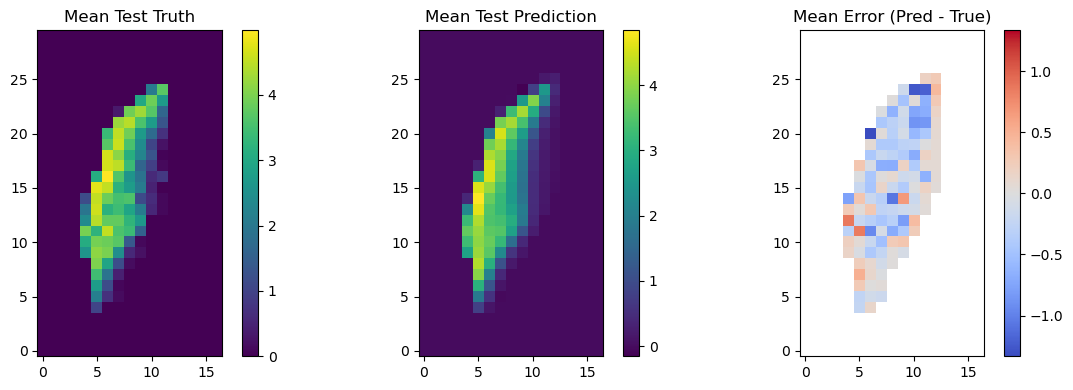

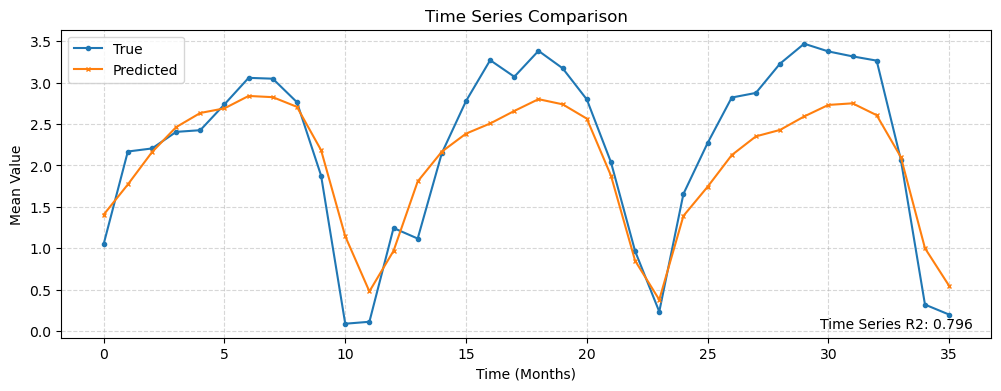

--------------------------------Iteration 2/10------------------------------------------------------------------------------------------------------
RMSE: 1.6773
Normalized RMSE: 0.1430 (14.30%)
MAE: 1.1653
R2: 0.5872
Pearson R: 0.7679
MBE: -0.0812
Wasserstein Distance: 0.8157
Spearman Rank Correlation: 0.73

--- Hotspot Hit Rate (Top 20% Overlap) ---
Total Hit Rate                        : 55.6667%
Mean Yearly Hit Rate                : 55.000%
Mean Monthly Hit Rate               : 40.436%
Mean Masked SSIM: 0.5350



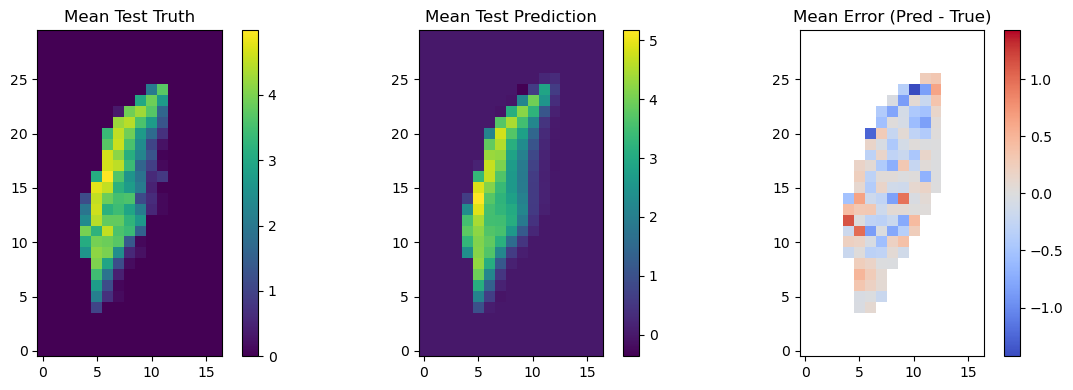

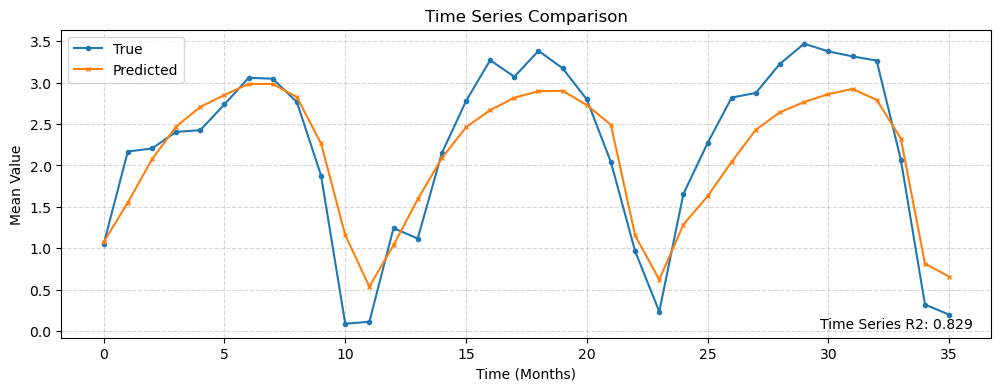

--------------------------------Iteration 3/10------------------------------------------------------------------------------------------------------
RMSE: 1.6830
Normalized RMSE: 0.1435 (14.35%)
MAE: 1.1636
R2: 0.5844
Pearson R: 0.7650
MBE: -0.0559
Wasserstein Distance: 0.7986
Spearman Rank Correlation: 0.73

--- Hotspot Hit Rate (Top 20% Overlap) ---
Total Hit Rate                        : 56.5556%
Mean Yearly Hit Rate                : 55.111%
Mean Monthly Hit Rate               : 39.300%
Mean Masked SSIM: 0.5332



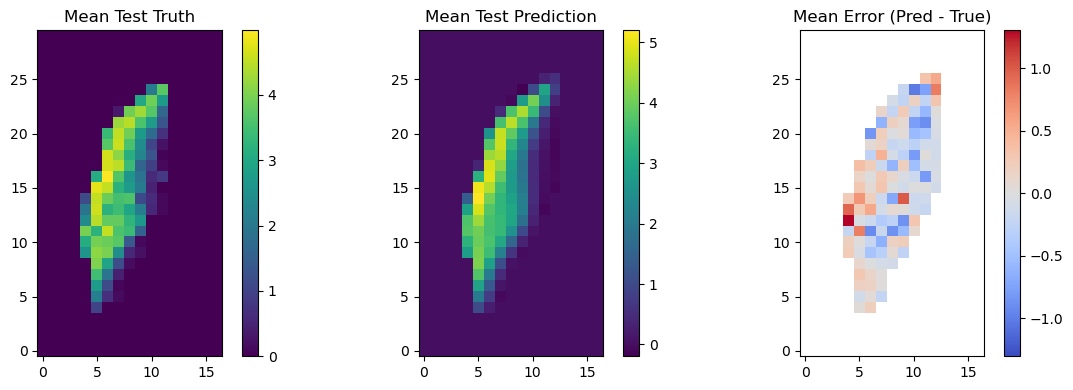

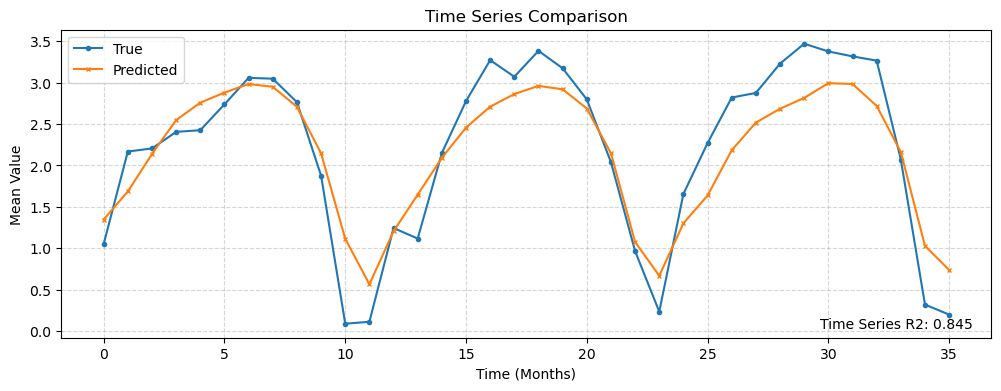

--------------------------------Iteration 4/10------------------------------------------------------------------------------------------------------
RMSE: 1.6965
Normalized RMSE: 0.1447 (14.47%)
MAE: 1.1732
R2: 0.5776
Pearson R: 0.7669
MBE: -0.2155
Wasserstein Distance: 0.8350
Spearman Rank Correlation: 0.73

--- Hotspot Hit Rate (Top 20% Overlap) ---
Total Hit Rate                        : 56.7778%
Mean Yearly Hit Rate                : 55.889%
Mean Monthly Hit Rate               : 39.214%
Mean Masked SSIM: 0.4838



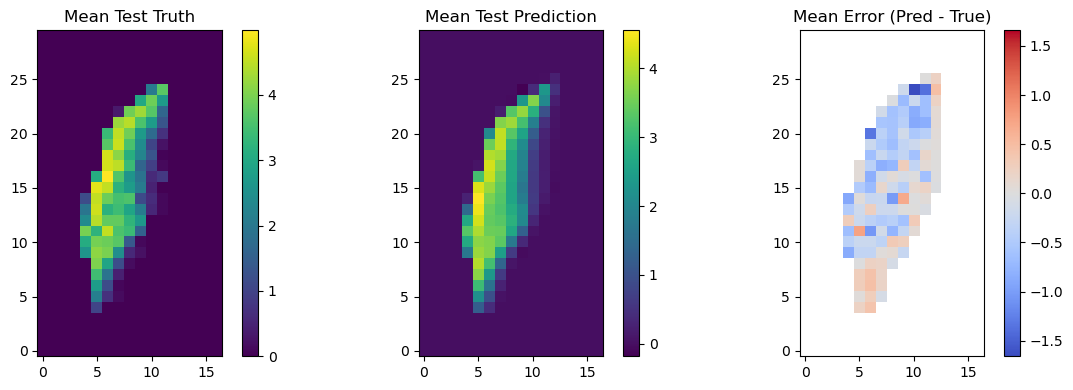

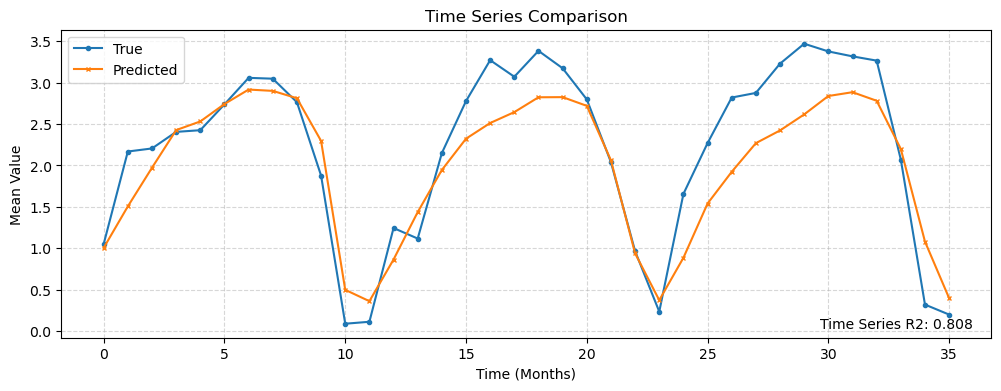

--------------------------------Iteration 5/10------------------------------------------------------------------------------------------------------
RMSE: 1.6872
Normalized RMSE: 0.1439 (14.39%)
MAE: 1.1503
R2: 0.5822
Pearson R: 0.7648
MBE: -0.1075
Wasserstein Distance: 0.7792
Spearman Rank Correlation: 0.73

--- Hotspot Hit Rate (Top 20% Overlap) ---
Total Hit Rate                        : 56.4444%
Mean Yearly Hit Rate                : 55.778%
Mean Monthly Hit Rate               : 37.992%
Mean Masked SSIM: 0.5150



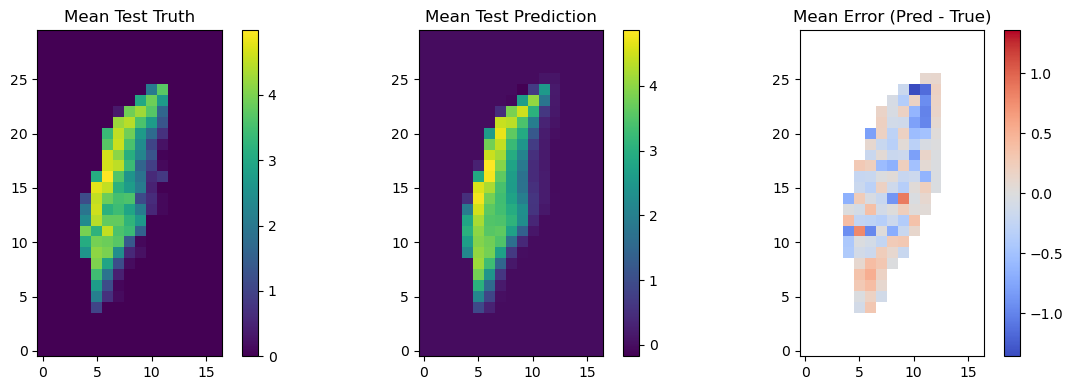

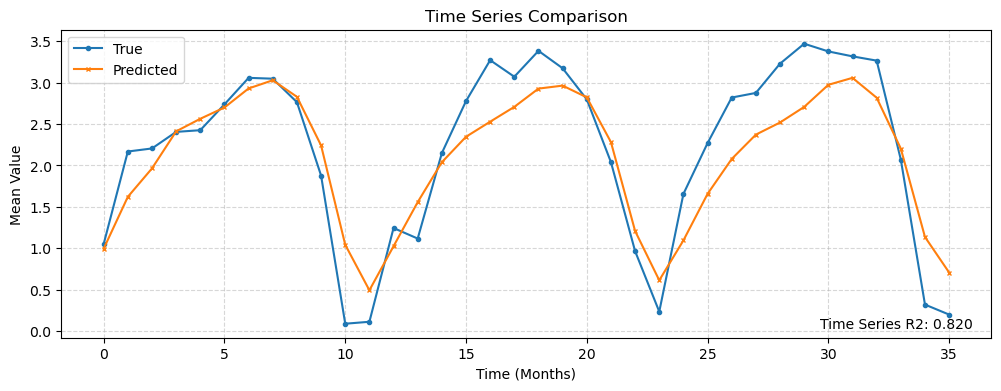

--------------------------------Iteration 6/10------------------------------------------------------------------------------------------------------
RMSE: 1.7086
Normalized RMSE: 0.1457 (14.57%)
MAE: 1.1630
R2: 0.5716
Pearson R: 0.7577
MBE: -0.1205
Wasserstein Distance: 0.7722
Spearman Rank Correlation: 0.72

--- Hotspot Hit Rate (Top 20% Overlap) ---
Total Hit Rate                        : 53.5556%
Mean Yearly Hit Rate                : 53.444%
Mean Monthly Hit Rate               : 38.325%
Mean Masked SSIM: 0.5259



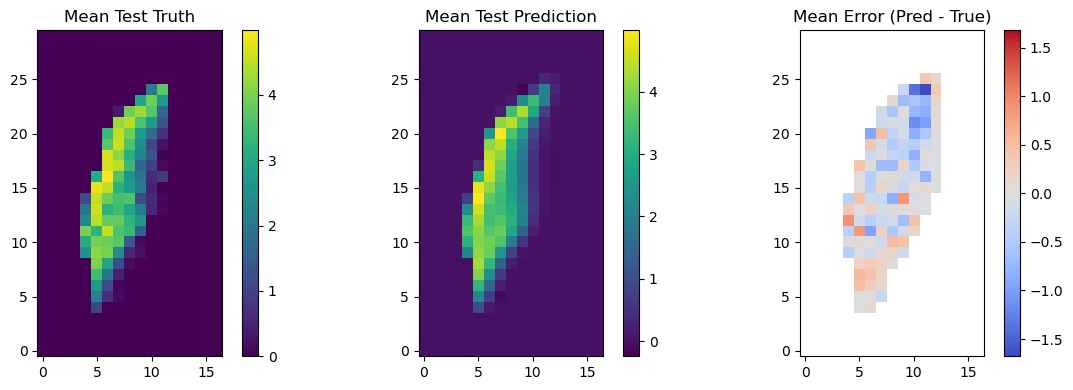

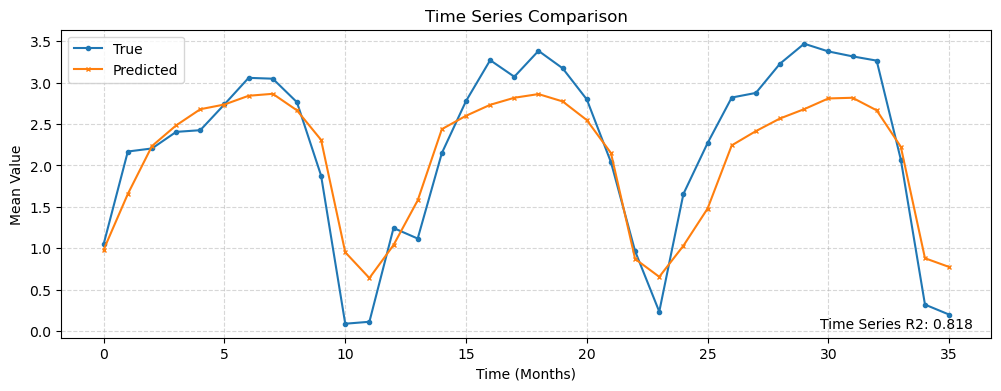

--------------------------------Iteration 7/10------------------------------------------------------------------------------------------------------
RMSE: 1.6924
Normalized RMSE: 0.1443 (14.43%)
MAE: 1.1376
R2: 0.5797
Pearson R: 0.7634
MBE: -0.1432
Wasserstein Distance: 0.7550
Spearman Rank Correlation: 0.73

--- Hotspot Hit Rate (Top 20% Overlap) ---
Total Hit Rate                        : 56.3333%
Mean Yearly Hit Rate                : 55.000%
Mean Monthly Hit Rate               : 40.658%
Mean Masked SSIM: 0.4470



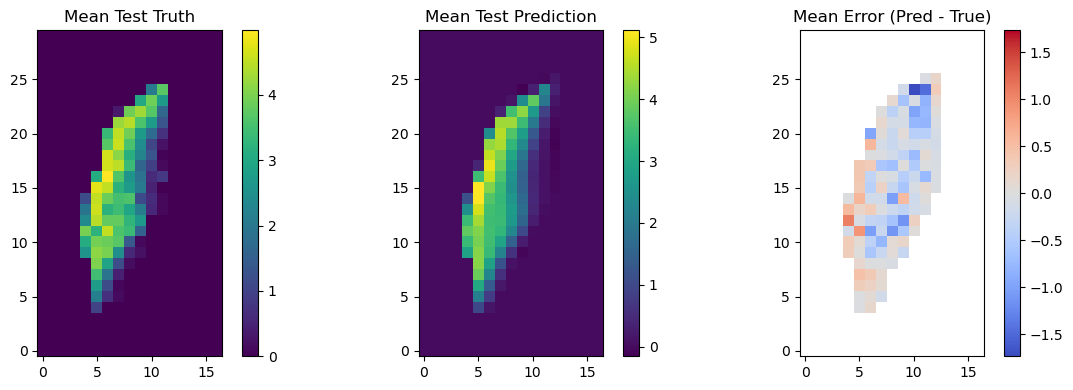

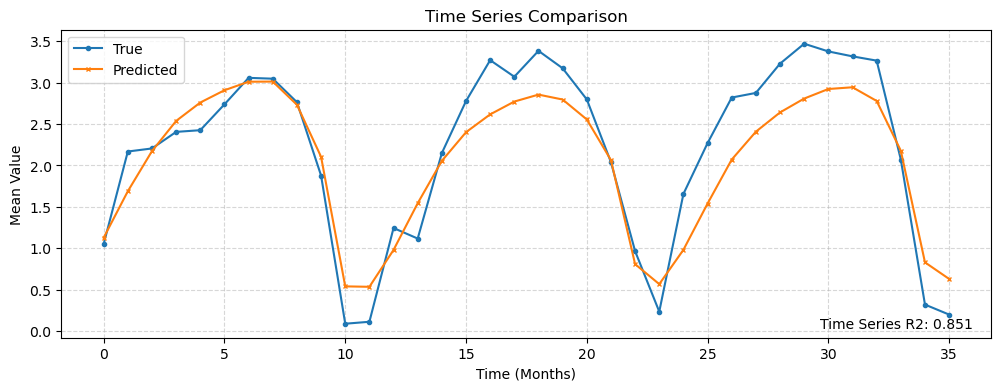

--------------------------------Iteration 8/10------------------------------------------------------------------------------------------------------
RMSE: 1.7184
Normalized RMSE: 0.1465 (14.65%)
MAE: 1.2070
R2: 0.5667
Pearson R: 0.7645
MBE: -0.2765
Wasserstein Distance: 0.8905
Spearman Rank Correlation: 0.73

--- Hotspot Hit Rate (Top 20% Overlap) ---
Total Hit Rate                        : 54.8889%
Mean Yearly Hit Rate                : 53.111%
Mean Monthly Hit Rate               : 39.769%
Mean Masked SSIM: 0.4780



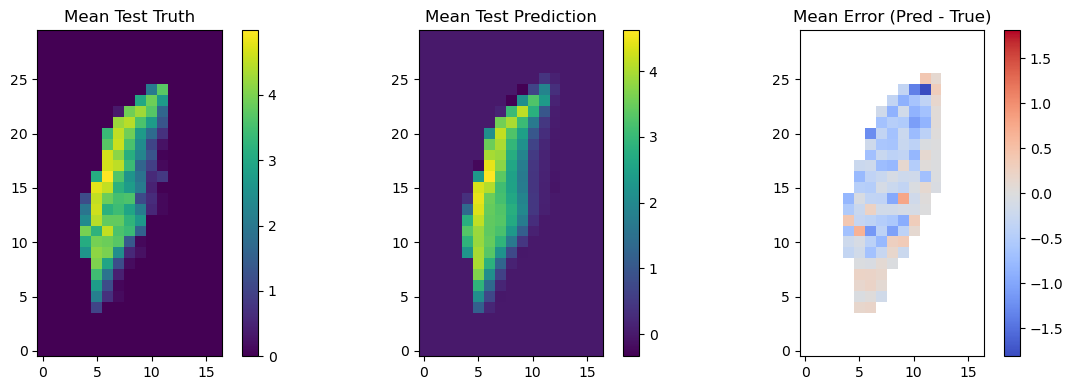

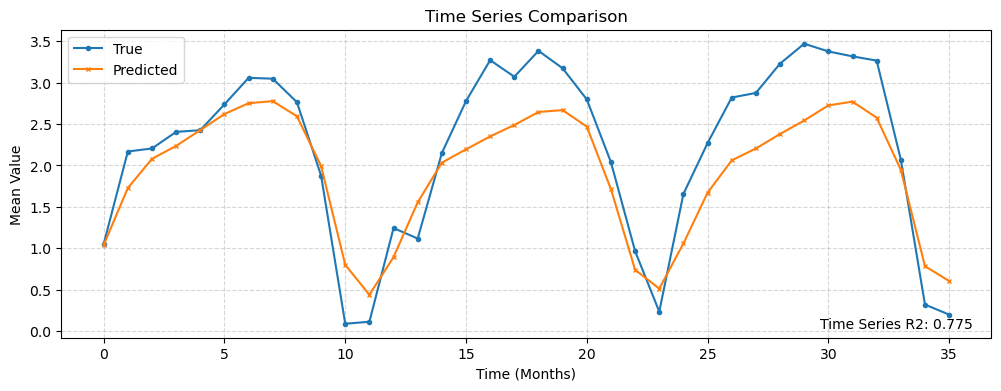

--------------------------------Iteration 9/10------------------------------------------------------------------------------------------------------
RMSE: 1.7090
Normalized RMSE: 0.1457 (14.57%)
MAE: 1.1326
R2: 0.5714
Pearson R: 0.7623
MBE: -0.2482
Wasserstein Distance: 0.7633
Spearman Rank Correlation: 0.72

--- Hotspot Hit Rate (Top 20% Overlap) ---
Total Hit Rate                        : 55.0000%
Mean Yearly Hit Rate                : 54.333%
Mean Monthly Hit Rate               : 39.067%
Mean Masked SSIM: 0.5183



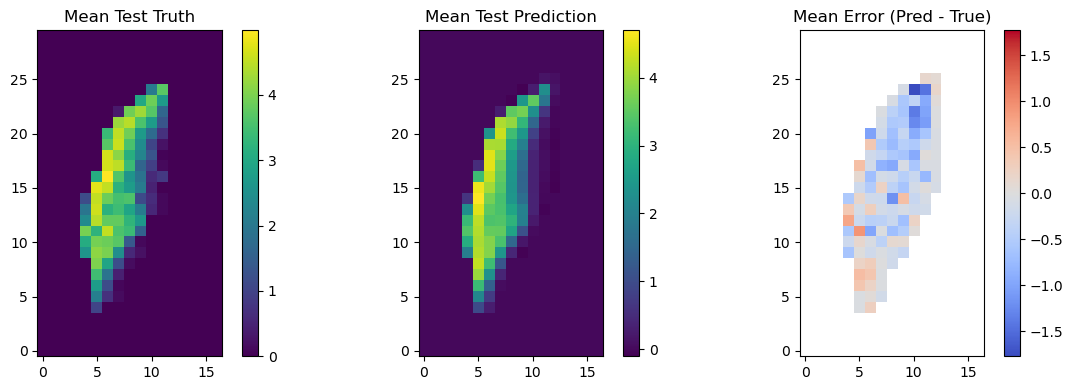

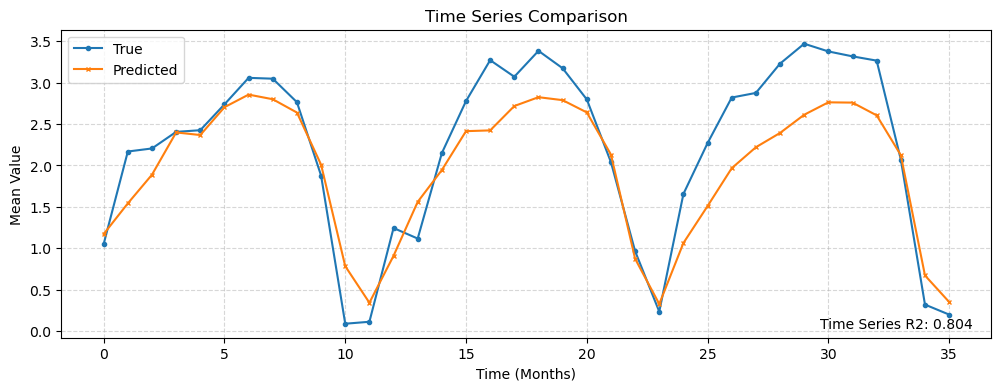

--------------------------------Iteration 10/10------------------------------------------------------------------------------------------------------
RMSE: 1.7011
Normalized RMSE: 0.1450 (14.50%)
MAE: 1.1496
R2: 0.5753
Pearson R: 0.7590
MBE: -0.0579
Wasserstein Distance: 0.7467
Spearman Rank Correlation: 0.72

--- Hotspot Hit Rate (Top 20% Overlap) ---
Total Hit Rate                        : 54.0000%
Mean Yearly Hit Rate                : 53.111%
Mean Monthly Hit Rate               : 37.903%
Mean Masked SSIM: 0.5042



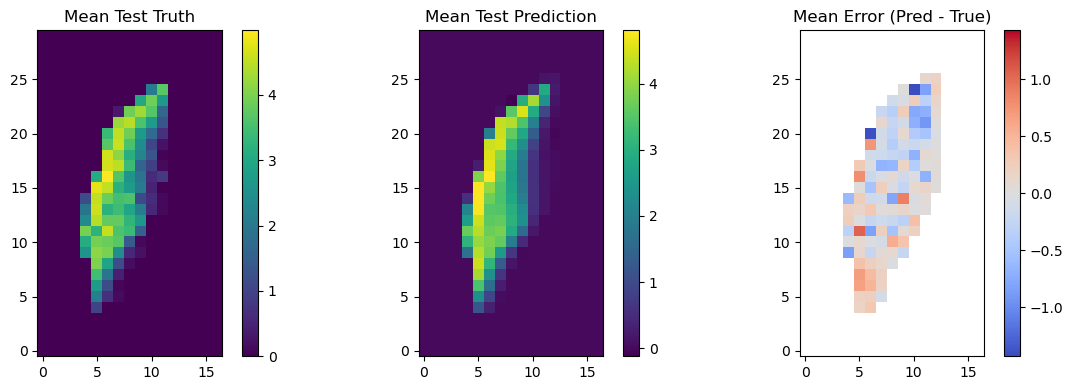

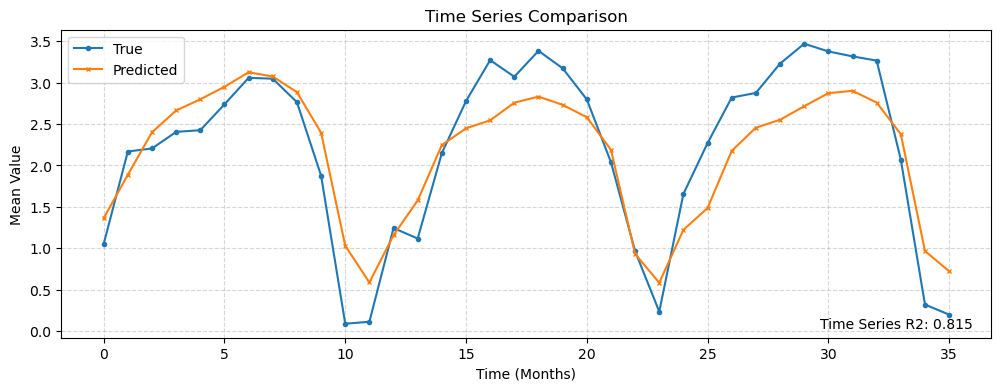

In [65]:
columns = ["r2", "pearson_corr", "r2_plot","mean_ssim", "rmse", "nrmse", "mae", "mbe", "w_dist", "spearman_corr", "hit_rate_percent", "mean_yearly_hit_rate", "mean_monthly_hit_rate"]
metrics_df = pd.DataFrame(columns=columns)
time_series_list = []

for i in range(iters):
    print(f"--------------------------------Iteration {i+1}/{iters}------------------------------------------------------------------------------------------------------")
    model.load_state_dict(torch.load(f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}.pth", map_location=device))
    model.to(device)
    model.eval()
    all_preds = []
    all_targets = []
    all_masks = []  

    with torch.no_grad():
        for x, y, m in test_loader:
            x = x.to(device)
            
            # Output shape: (B, H, W)
            pred = model(x).squeeze(1) 

            # Keep them raw; do not multiply by m here
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y.cpu().numpy())
            all_masks.append(m.cpu().numpy())

    # Concatenate along the batch dimension (N, H, W)
    all_preds = np.concatenate(all_preds, axis=0)     
    all_targets = np.concatenate(all_targets, axis=0) 
    all_masks = np.concatenate(all_masks, axis=0)

    mean_pred = all_preds.mean(axis=0)     # (H, W)
    mean_true = all_targets.mean(axis=0)   # (H, W)
    metrics, time_series, time_series_true = regression_metrics_dl(
        y_true=all_targets, 
        y_pred=all_preds, 
        mask_spatial=all_masks
    )
    time_series_list.append(time_series)
    metrics_df.loc[len(metrics_df)] = metrics




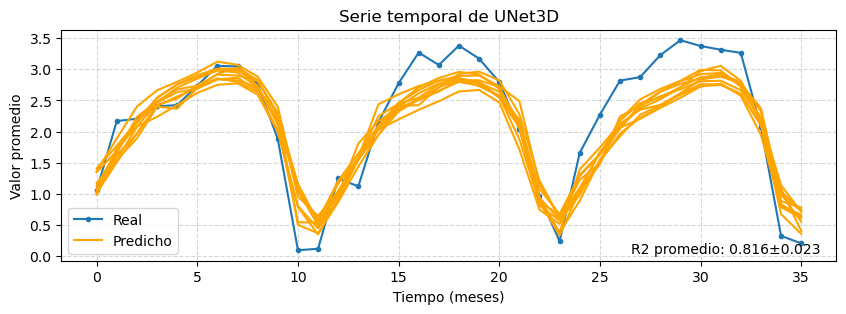

In [66]:
plt.figure(figsize=(10, 3))
plt.plot(time_series_true, label="Real", marker='o', markersize=3)
for i in range(len(time_series_list)-1):
    plt.plot(time_series_list[i], color="orange")
plt.plot(time_series_list[i+1], color="orange", label="Predicho")

plt.annotate(f"R2 promedio: {metrics_df['r2_plot'].mean():.3f}±{metrics_df['r2_plot'].std():.3f}", xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom')
plt.xlabel("Tiempo (meses)")
plt.ylabel("Valor promedio")
plt.title(f"Serie temporal de {model_name}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
img_buffer2 = BytesIO()
plt.savefig(img_buffer2, format="png", bbox_inches="tight")
img_buffer2.seek(0)
plt.show()



In [67]:
display(metrics_df)

metrics_summary_df = pd.DataFrame(
    {col: [f"{metrics_df[col].mean():.3f}±{metrics_df[col].std():.3f}"]for col in metrics_df.columns})

display(metrics_summary_df)

,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr,hit_rate_percent,mean_yearly_hit_rate,mean_monthly_hit_rate
0,0.577433,0.764399,0.795841,0.526011,1.696933,0.144690,1.174756,-0.157308,0.827954,0.726026,54.666667,53.333333,39.706186
1,0.587154,0.767937,0.828938,0.535034,1.677301,0.143016,1.165327,-0.081204,0.815721,0.729501,55.666667,55.000000,40.435981
2,0.584355,0.765022,0.845425,0.533194,1.682976,0.143500,1.163636,-0.055896,0.798613,0.726569,56.555556,55.111111,39.299845
3,0.577628,0.766877,0.807512,0.483757,1.696542,0.144657,1.173233,-0.215534,0.834962,0.729131,56.777778,55.888889,39.213759
4,0.582244,0.764785,0.820429,0.515017,1.687245,0.143864,1.150333,-0.107513,0.779238,0.727577,56.444444,55.777778,37.991537
5,0.571597,0.757709,0.817877,0.525881,1.708611,0.145686,1.163017,-0.120517,0.772159,0.717638,53.555556,53.444444,38.324870
6,0.579706,0.763421,0.850901,0.447048,1.692364,0.144301,1.137591,-0.143231,0.755035,0.728688,56.333333,55.000000,40.658204
7,0.566666,0.764489,0.775106,0.477962,1.718416,0.146522,1.207035,-0.276470,0.890457,0.725454,54.888889,53.111111,39.769315
8,0.571412,0.762306,0.804367,0.518284,1.708981,0.145717,1.132602,-0.248242,0.763312,0.724884,55.000000,54.333333,39.066612
9,0.575339,0.758982,0.814533,0.504208,1.701132,0.145048,1.149591,-0.057873,0.746664,0.719068,54.000000,53.111111,37.903383


,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr,hit_rate_percent,mean_yearly_hit_rate,mean_monthly_hit_rate
0,0.577±0.006,0.764±0.003,0.816±0.023,0.507±0.029,1.697±0.013,0.145±0.001,1.162±0.021,-0.146±0.078,0.798±0.045,0.725±0.004,55.389±1.135,54.411±1.091,39.237±0.952


In [68]:
graph_model = UNet3D(
    in_channels=X_test.shape[2],
    out_hw=(y_test.shape[1], y_test.shape[2]),
    base_ch=8
)
graph_model_name = graph_model.__class__.__name__

graph = draw_graph(
    graph_model,
    input_size=(1, X_test.shape[1], X_test.shape[2], X_test.shape[3], X_test.shape[4]),
    expand_nested=True,
    roll=True,
    )

graph.visual_graph.graph_attr.update(dpi="200")


graph.visual_graph.render(f"./modelos/{graph_model_name}", format="png")

print(graph_model)

import torch

graph_model.eval().cpu()
dummy_input = torch.randn(1, X_test.shape[1], X_test.shape[2], X_test.shape[3], X_test.shape[4])

exported_program = torch.export.export(
    graph_model,
    args=(dummy_input,),
)

torch.export.save(exported_program, f"./modelos/{graph_model_name}.pt2")

couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.

UNet3D(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv3d(7, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout3d(p=0.35, inplace=False)
      (4): Conv3d(8, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (5): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
    )
  )
  (pool1): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout3d(p=0.35, inplace=False)
      (4): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (5): BatchNorm3d(16, eps=1e-05

In [69]:
def evaluate_with_zeroed_channel(model, loader, channel_to_zero, device):
    model.eval()
    
    total_loss = 0.0
    total_r2 = 0.0
    total_ssim = 0.0
    total_samples = 0

    with torch.no_grad():
        for x, y, m in loader:
            x = x.clone().to(device)
            y = y.to(device)
            m = m.to(device)
            
            batch_size = x.size(0)

            if isinstance(channel_to_zero, int):
                x[:, :, channel_to_zero, :, :] = 0
            if channel_to_zero ==  "all":
                x[:, :, :, :, :] = 0

            pred = model(x)
            loss = criterion(pred, y, m)
            pred_matched = pred.view_as(y)
            
            # --- GPU R2 Score (Mask-Aware) ---
            m_bool = m > 0.5
            y_true_flat = y[m_bool]
            y_pred_flat = pred_matched[m_bool]

            if y_true_flat.numel() > 1 and torch.var(y_true_flat) > 0:
                r2 = torch_r2_score(y_pred_flat, y_true_flat)
            else:
                r2 = torch.tensor(0.0, device=device)

            H, W = y.shape[-2], y.shape[-1]
            y_slices = y.reshape(-1, 1, H, W)
            pred_slices = pred.reshape(-1, 1, H, W)
            
            # Dynamic data range calculation on GPU
            data_range = torch.clamp(y_slices.max() - y_slices.min(), min=1e-5)
            
            ssim_val = structural_similarity_index_measure(
                pred_slices, y_slices, data_range=data_range
            )

            # Weight metrics by batch size for an exact dataset-wide average
            total_loss += loss.item() * batch_size
            total_r2 += r2.item() * batch_size
            total_ssim += ssim_val.item() * batch_size
            total_samples += batch_size

    return (
        total_loss / total_samples, 
        total_r2 / total_samples, 
        total_ssim / total_samples
    )


all_importances = []

for i in range(iters):
    #compute baseline
    model.load_state_dict(torch.load(
        f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}.pth",
        map_location=device
    ))
    model.to(device)

    baseline_loss, baseline_r2, baseline_ssim = evaluate_with_zeroed_channel(
        model, test_loader, channel_to_zero=None, device=device
    )

    loss_importances = []
    r2_importances = []
    ssim_importances = []

    features_names = vars_names.copy()

    #compute importance for each channel
    for c in range(in_channels):
        loss, r2, ssim_val = evaluate_with_zeroed_channel(
            model, test_loader, channel_to_zero=c, device=device
        )

        loss_importances.append(loss - baseline_loss)
        r2_importances.append(baseline_r2 - r2)
        ssim_importances.append(baseline_ssim - ssim_val)

    df_importance = pd.DataFrame({
        "variable": features_names,
        "r2_importance": r2_importances,
        "ssim_importance": ssim_importances,
        "loss_importance": loss_importances,
    })

    df_importance["r2_drop_%"] = (
        df_importance["r2_importance"] / baseline_r2 * 100
    )

    all_importances.append(df_importance)

# Concatenate all model importances
all_df = pd.concat(all_importances, ignore_index=True)

# Compute mean and std for each variable
mean_df = all_df.groupby("variable").mean(numeric_only=True)
std_df = all_df.groupby("variable").std(numeric_only=True)

# Build "mean ± std" table
summary_df = pd.DataFrame(index=mean_df.index)

for col in mean_df.columns:
    summary_df[col] = [
        f"{m:.4f} ± {s:.4f}"
        for m, s in zip(mean_df[col], std_df[col])
    ]

# Sort using the numeric mean r2_importance
summary_df = summary_df.loc[
    mean_df["r2_importance"].sort_values(ascending=False).index
].reset_index()

display(summary_df)

,variable,r2_importance,ssim_importance,loss_importance,r2_drop_%
0,ugo,0.0701 ± 0.0386,0.0048 ± 0.0204,0.2727 ± 0.1486,12.1892 ± 6.6992
1,vgo,0.0603 ± 0.0352,-0.0005 ± 0.0207,0.2472 ± 0.1391,10.5073 ± 6.1945
2,mlotst,0.0587 ± 0.0388,0.0214 ± 0.0117,0.2037 ± 0.1419,10.2089 ± 6.7686
3,to,0.0391 ± 0.0123,0.0080 ± 0.0121,0.1505 ± 0.0477,6.7947 ± 2.1207
4,month_sin,0.0177 ± 0.0100,0.0054 ± 0.0090,0.0613 ± 0.0400,3.0774 ± 1.7209
5,month_cos,0.0171 ± 0.0148,0.0049 ± 0.0074,0.0557 ± 0.0528,2.9645 ± 2.5735
6,CDM,0.0092 ± 0.0057,0.0046 ± 0.0101,0.0338 ± 0.0214,1.6026 ± 0.9920


In [70]:
# save everyhtng to a excel workbook
with pd.ExcelWriter("./modelos/resultados/Regre/DL_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    sheet_name = f"{model_name}_{sp}"
    metrics_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

with pd.ExcelWriter("./modelos/resultados/Regre/DL_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    sheet_name = f"{model_name}_{sp}"
    summary_df.to_excel(writer, sheet_name=sheet_name, startrow=len(metrics_summary_df) + 3, index=False)
    ws = writer.sheets[sheet_name]
    img1 = Image(img_buffer1)
    ws.add_image(img1, f"N1")
    img2 = Image(img_buffer2)
    ws.add_image(img2, f"N20")